# Consumption Models with Habit Formation: figures

This notebook illustrates the [habit formation handout](../content/consumption/Habits.md).
<!-- Provenance: the handout's source zip,
https://www.econ2.jhu.edu/people/ccarroll/public/LectureNotes/Consumption/Habits.zip,
contains only LaTeX and the PDF, with no Mathematica code or figures. The figures
here are new, not reproductions. -->

The first part solves the handout's own model, in which utility is
$\mathbf{f}(c_{t}-\alpha h_{t})$ and the habit stock is last period's consumption.
Without income risk it has a closed-form solution, which we use to check the
handout's Euler equation and its approximation

$$\Delta \log c_{t+1} \approx (1-\alpha)\rho^{-1}(r-\vartheta) + \alpha\, \Delta \log c_{t}.$$

The second part uses HARK's `HabitConsumerType`, which adds income risk, to show
how habits change the consumption function and the response of consumption to an
income shock.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from HARK.ConsumptionSaving.ConsHabitModel import HabitConsumerType
from HARK.ConsumptionSaving.ConsIndShockModel import IndShockConsumerType

FIG_DIR = Path("figures") / "Habits"
FIG_DIR.mkdir(parents=True, exist_ok=True)

## Part 1: the handout's model

The consumer maximizes $\sum_{t} \beta^{t} \mathbf{f}(c_{t}-\alpha c_{t-1})$ with
$\mathbf{f}(z)=z^{1-\rho}/(1-\rho)$, subject to an intertemporal budget constraint
with total wealth $W$ (financial plus human) at date $0$, and an inherited habit
$c_{-1}$.

The handout shows that marginal utility $\mathbf{f}^{\prime}(z_{t})$ falls at rate
$R\beta$, so $z_{t} = c_{t}-\alpha c_{t-1}$ grows at the constant factor
$g = (R\beta)^{1/\rho}$. Consumption itself is then

$$c_{t} = \alpha c_{t-1} + z_{0} g^{t},$$

and the budget constraint pins down $z_{0}$:

$$\sum_{t=0}^{\infty} R^{-t} c_{t} = W
\quad\Longrightarrow\quad
z_{0} = \left(W - \frac{\alpha c_{-1}}{1-\alpha/R}\right)\left(1-\frac{\alpha}{R}\right)\left(1-\frac{g}{R}\right).$$

In [2]:
R = 1.04
beta = 0.98
rho = 2.0
r = R - 1
vartheta = 1 / beta - 1  # time preference rate, beta = 1/(1+vartheta)
g = (R * beta) ** (1 / rho)

W = 35.0
c_prev = 0.7
alphas = [0.0, 0.5, 0.8]
T = 41


def habit_path(alpha, W, c_prev, T):
    """Optimal consumption c_0..c_{T-1} in the handout's model, and z_t = c_t - alpha c_{t-1}."""
    z0 = (W - alpha * c_prev / (1 - alpha / R)) * (1 - alpha / R) * (1 - g / R)
    c = np.empty(T)
    last = c_prev
    for t in range(T):
        c[t] = alpha * last + z0 * g**t
        last = c[t]
    return c, z0 * g ** np.arange(T)


paths = {alpha: habit_path(alpha, W, c_prev, T) for alpha in alphas}
for alpha, (c, z) in paths.items():
    print(f"alpha = {alpha}:  c_0 = {c[0]:.4f}   c_10 = {c[10]:.4f}   c_40 = {c[40]:.4f}")

alpha = 0.0:  c_0 = 1.0246   c_10 = 1.1268   c_40 = 1.4988
alpha = 0.5:  c_0 = 0.8718   c_10 = 1.1367   c_40 = 1.5122
alpha = 0.8:  c_0 = 0.7801   c_10 = 1.1358   c_40 = 1.5508


### Checks against the handout

The path satisfies the handout's Euler equation (the equation labelled
`eq:vpeq`),

$$\mathbf{f}_{t}^{\prime}-\alpha \beta \mathbf{f}_{t+1}^{\prime} = R\beta[\mathbf{f}_{t+1}^{\prime} -\alpha \beta \mathbf{f}_{t+2}^{\prime}],$$

and it exhausts total wealth. Together these make it the optimal path.

In [3]:
for alpha in alphas:
    c, z = habit_path(alpha, W, c_prev, 5000)
    fp = z ** (-rho)
    lhs = fp[:-2] - alpha * beta * fp[1:-1]
    rhs = R * beta * (fp[1:-1] - alpha * beta * fp[2:])
    assert np.allclose(lhs, rhs, rtol=1e-10)
    pdv = np.sum(c / R ** np.arange(c.size))
    assert np.isclose(pdv, W, rtol=1e-8)
print("Euler equation and budget constraint hold for every alpha.")

Euler equation and budget constraint hold for every alpha.


### Consumption paths

With $\alpha=0$ consumption grows at the constant rate $\log g$ from the start. With
habits, a consumer whose habit $c_{-1}$ is below what his wealth can support raises
consumption gradually, because a sudden jump would raise next period's habit stock.
The stronger the habit, the lower consumption starts and the longer it takes to
reach its long-run growth rate.

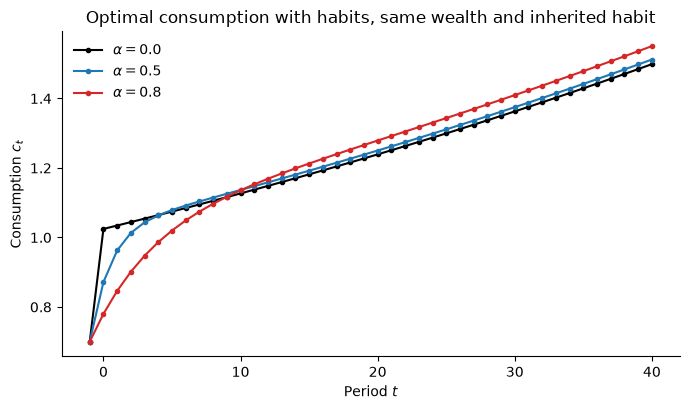

In [4]:
colors = {0.0: "black", 0.5: "tab:blue", 0.8: "tab:red"}

fig, ax = plt.subplots(figsize=(7, 4.2))
for alpha, (c, _) in paths.items():
    ax.plot(np.arange(-1, T), np.concatenate(([c_prev], c)), "o-", ms=3, color=colors[alpha], label=rf"$\alpha={alpha}$")
ax.set_xlabel("Period $t$")
ax.set_ylabel("Consumption $c_t$")
ax.set_title("Optimal consumption with habits, same wealth and inherited habit")
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig(FIG_DIR / "HabitsCPath.png", dpi=200)
fig.savefig(FIG_DIR / "HabitsCPath.svg")
plt.show()

### Serial correlation of consumption growth

Each point pairs consumption growth in one period with growth in the next, along
the optimal paths above. The lines are the handout's approximation,
$\Delta \log c_{t+1} \approx (1-\alpha)\rho^{-1}(r-\vartheta) + \alpha\, \Delta \log c_{t}$.
The slope is $\alpha$: with habits, consumption growth is serially correlated. The
approximation is close once growth rates are small and drifts away for the large
early growth rates. Without habits the inherited $c_{-1}$ plays no role, so the jump
from it to $c_{0}$ is left out for $\alpha=0$.

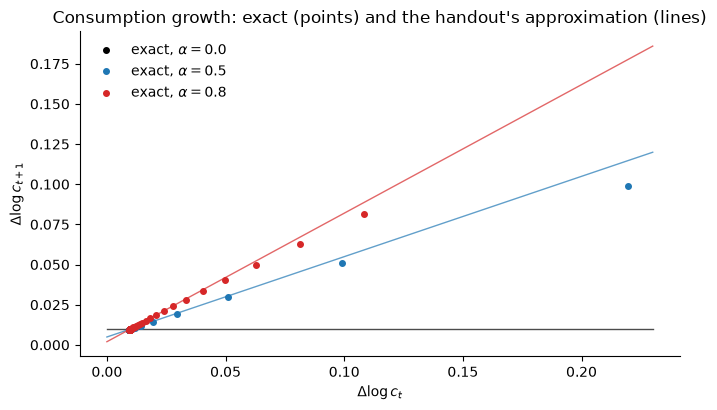

In [5]:
fig, ax = plt.subplots(figsize=(7, 4.2))
for alpha, (c, _) in paths.items():
    dlogc = np.diff(np.log(np.concatenate(([c_prev], c))))
    if alpha == 0.0:
        dlogc = dlogc[1:]
    ax.plot(dlogc[:-1], dlogc[1:], "o", ms=4, color=colors[alpha], label=rf"exact, $\alpha={alpha}$")
    grid = np.linspace(0, 0.23, 50)
    ax.plot(grid, (1 - alpha) * (r - vartheta) / rho + alpha * grid, "-", lw=1, color=colors[alpha], alpha=0.7)
ax.set_xlabel(r"$\Delta \log c_{t}$")
ax.set_ylabel(r"$\Delta \log c_{t+1}$")
ax.set_title("Consumption growth: exact (points) and the handout's approximation (lines)")
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig(FIG_DIR / "HabitsGrowthCorr.png", dpi=200)
fig.savefig(FIG_DIR / "HabitsGrowthCorr.svg")
plt.show()

In [6]:
for alpha, (c, _) in paths.items():
    dlogc = np.diff(np.log(np.concatenate(([c_prev], c))))
    if alpha == 0.0:
        assert np.allclose(dlogc[1:], np.log(g))
        print(f"alpha = 0.0: growth is constant at log g = {np.log(g):.4f}")
        continue
    slope = np.polyfit(dlogc[5:-1], dlogc[6:], 1)[0]
    print(f"alpha = {alpha}: fitted slope of growth on lagged growth = {slope:.3f}")
    assert abs(slope - alpha) < 0.05

alpha = 0.0: growth is constant at log g = 0.0095
alpha = 0.5: fitted slope of growth on lagged growth = 0.494
alpha = 0.8: fitted slope of growth on lagged growth = 0.779


## Part 2: habits with income risk, in HARK

HARK's `HabitConsumerType` solves a buffer-stock model with habits and permanent and
transitory income shocks. Its utility function is multiplicative rather than the
handout's subtractive form,

$$u(c,h) = \frac{(c/h^{\alpha})^{1-\rho}}{1-\rho},$$

and the habit stock updates as $H_{t} = \lambda c_{t} + (1-\lambda) h_{t}$. We set
$\lambda=1$, the case the handout analyzes, and $\alpha=0.5$. The comparison is
HARK's `IndShockConsumerType` with the same parameters and no habits.

<!-- HabitConsumerType's infinite-horizon solve (cycles=0) stops after two periods
because its convergence distance comes back as nan, so we solve a long finite
horizon and use the first-period solution, checking that it has converged. With the
default grids the solver is only reliable near alpha=0.5: alpha=0.1 does not settle
and alpha=0.8 degenerates to consuming everything. -->

In [7]:
params = dict(CRRA=2.0, Rfree=[1.03], DiscFac=0.96, LivPrb=[0.98], PermGroFac=[1.01], BoroCnstArt=0.0)
RfreeB, GB = 1.03, 1.01

no_habit = IndShockConsumerType(cycles=0, **params)
no_habit.solve()
cFunc_none = no_habit.solution[0].cFunc

habit = HabitConsumerType(cycles=60, **params, HabitWgt=0.5, HabitRte=1.0)
habit.solve()
cFunc_habit = habit.solution[0]["cFunc"]

m_check = np.linspace(0.5, 5.0, 20)
drift = np.abs(
    cFunc_habit(m_check, np.ones_like(m_check)) - habit.solution[20]["cFunc"](m_check, np.ones_like(m_check))
).max()
print(f"largest change in c(m, h=1) over the last 20 periods: {drift:.1e}")
assert drift < 1e-3

largest change in c(m, h=1) over the last 20 periods: 7.6e-04


### The consumption function

With habits, consumption depends on the habit stock as well as on market
resources. A consumer with a higher habit stock consumes more at the same $m$.

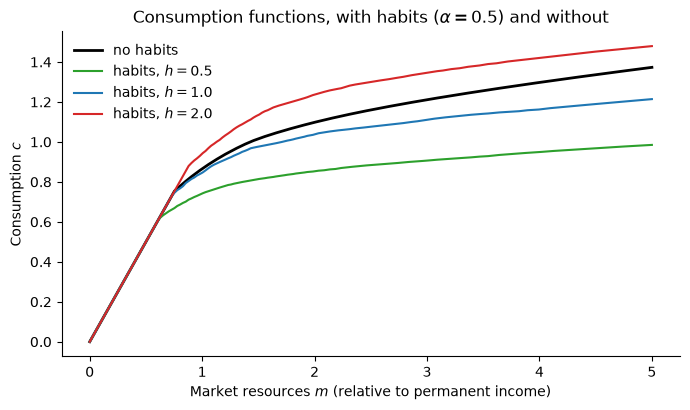

In [8]:
m_grid = np.linspace(0.0, 5.0, 200)
fig, ax = plt.subplots(figsize=(7, 4.2))
ax.plot(m_grid, cFunc_none(m_grid), color="black", lw=2, label="no habits")
for h, color in zip((0.5, 1.0, 2.0), ("tab:green", "tab:blue", "tab:red")):
    ax.plot(m_grid, cFunc_habit(m_grid, h * np.ones_like(m_grid)), color=color, label=rf"habits, $h={h}$")
ax.set_xlabel("Market resources $m$ (relative to permanent income)")
ax.set_ylabel("Consumption $c$")
ax.set_title(r"Consumption functions, with habits ($\alpha=0.5$) and without")
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig(FIG_DIR / "HabitsCFunc.png", dpi=200)
fig.savefig(FIG_DIR / "HabitsCFunc.svg")
plt.show()

### Response to a one-time income shock

Starting from the point where the consumer would stay if income were always at its
mean, he receives a transitory shock $\theta_{t}=2$ in period $t$ and no shocks
afterward. Without habits consumption jumps on impact and then decays. With habits
the impact response is smaller, consumption keeps rising for another period, and
only then declines, staying above the no-habit path for longer: the response is
hump-shaped and persistent, which is the serial correlation of consumption growth
from Part 1.

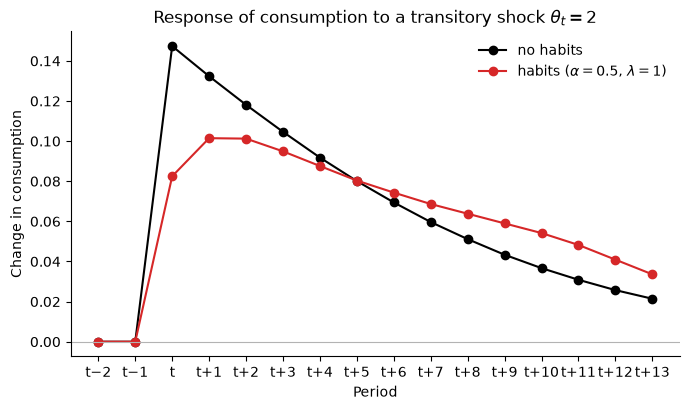

In [9]:
periods = np.arange(-2, 14)
shock_at = 2


def shock_response(consume, habit_state):
    """Consumption path around a one-time shock theta_t = 2, from the no-shock rest point."""
    m, h = 1.0, 1.0
    for _ in range(3000):
        c = consume(m, h)
        m, h = (m - c) * RfreeB / GB + 1.0, (c / GB if habit_state else h)
    theta = np.ones(periods.size)
    theta[shock_at] = 2.0
    path = np.empty(periods.size)
    for t in range(periods.size):
        if t > 0:
            m, h = (m - c) * RfreeB / GB + theta[t], (c / GB if habit_state else h)
        c = consume(m, h)
        path[t] = c
    return path


c_none = shock_response(lambda m, h: float(cFunc_none(m)), habit_state=False)
c_habit = shock_response(lambda m, h: float(cFunc_habit(m, h)), habit_state=True)

dc_none = c_none - c_none[0]
dc_habit = c_habit - c_habit[0]
assert dc_habit[shock_at] < dc_none[shock_at]
assert dc_habit[shock_at + 1] > dc_habit[shock_at]
assert dc_none[shock_at + 1] < dc_none[shock_at]

labels = ["t" if p == 0 else f"t{p:+d}" for p in periods]
fig, ax = plt.subplots(figsize=(7, 4.2))
ax.plot(periods, dc_none, "o-", color="black", label="no habits")
ax.plot(periods, dc_habit, "o-", color="tab:red", label=r"habits ($\alpha=0.5$, $\lambda=1$)")
ax.axhline(0, color="0.7", lw=0.8)
ax.set_xticks(periods, [lab.replace("-", "\u2212") for lab in labels])
ax.set_xlabel("Period")
ax.set_ylabel("Change in consumption")
ax.set_title(r"Response of consumption to a transitory shock $\theta_{t}=2$")
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig(FIG_DIR / "HabitsShockResponse.png", dpi=200)
fig.savefig(FIG_DIR / "HabitsShockResponse.svg")
plt.show()